In [ ]:
from google.colab import files
uploaded = files.upload()

Saving heart_disease.csv to heart_disease.csv


# Hands-on Exercise 1: Machine Learning Template for Classification
**Name:** Tanishtha Papadkar
**Course:** CIS 508  
**Assignment:** HW1  
**Dataset:** Heart Dataset  

## Objective
This notebook is a reusable machine learning template for a binary classification problem.  
The goal is to organize the machine learning process from beginning to end, including:

1. Problem Introduction & Motivation  
2. Data Preparation (EDA)  
3. Model Selection  
4. Model Evaluation  

This notebook emphasizes structure, planning, and transparency rather than complex modeling.

# 1. Problem Introduction & Motivation

## Business / Analytical Problem
In this project, the goal is to predict a binary target outcome using five predictor variables from a heart-related dataset. Because the target variable has only two possible values, this is a **classification problem**.

## Why This Problem Matters
Classification problems are common in business and healthcare because they help decision-makers predict outcomes and take action early. In a healthcare setting, a predictive model may help identify higher-risk patients faster, improve screening, and support better decision-making.

## Dataset Description
This dataset contains:
- **1 binary target variable** in the first column
- **5 predictor variables** in the remaining columns

The predictors may include a mix of numerical and possibly categorical variables. Before building a trustworthy model, the data must be inspected, cleaned, summarized, and prepared properly.

## ML Workflow Plan
This notebook follows four major steps:
1. Define the problem
2. Prepare and explore the data
3. Select a possible model
4. Describe how the model should be evaluated

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

seaborn

In [ ]:
import seaborn as sns

# 2. Data Preparation (EDA)

## Step 1: Load the Data
First, load the dataset and inspect its basic structure. This helps confirm the number of rows, columns, variable names, and data types.

In [ ]:
df = pd.read_csv('heart_disease.csv')
df.head()

,heart_disease,age,sex,max_heart_rate,angina_level,non_anginal_pain
0,0,69.0,male,131,No,0
1,0,69.0,female,151,No,0
2,0,NaN,female,114,No,0
3,1,65.0,male,174,No,0
4,0,64.0,male,144,Mild,0


In [ ]:
df.shape

(297, 6)

In [ ]:
df.columns

Index(['heart_disease', 'age', 'sex', 'max_heart_rate', 'angina_level',
       'non_anginal_pain'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   heart_disease     297 non-null    int64  
 1   age               268 non-null    float64
 2   sex               297 non-null    object 
 3   max_heart_rate    297 non-null    int64  
 4   angina_level      277 non-null    object 
 5   non_anginal_pain  297 non-null    int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 14.1+ KB


In [ ]:
df.describe()

,heart_disease,age,max_heart_rate,non_anginal_pain
count,297.000000,268.000000,297.000000,297.000000
mean,0.461279,54.250000,146.380471,0.279461
std,0.499340,9.039292,38.500000,0.449492
min,0.000000,29.000000,-170.000000,0.000000
25%,0.000000,47.750000,132.000000,0.000000
50%,0.000000,55.000000,152.000000,0.000000
75%,1.000000,60.000000,165.000000,1.000000
max,1.000000,77.000000,202.000000,1.000000


## Step 2: Identify the Target Variable and Predictor Variables
The first column is the binary target variable, and the remaining five columns are predictors.

In [ ]:
target = df.columns[0]
predictors = df.columns[1:]

print("Target variable:", target)
print("Predictor variables:", list(predictors))

Target variable: heart_disease
Predictor variables: ['age', 'sex', 'max_heart_rate', 'angina_level', 'non_anginal_pain']


## Step 3: Check for Missing Values
Missing values can reduce the quality of analysis and model performance. We need to identify whether any values are missing and decide how to handle them.

In [ ]:
df.isnull().sum()

,0
heart_disease,0
age,29
sex,0
max_heart_rate,0
angina_level,20
non_anginal_pain,0


In [ ]:
df.isnull().sum().sum()

np.int64(49)

## Step 3: Handling Missing Values

The dataset contains missing values. Specifically, there are **49 missing values** identified across the dataset.

Missing data can negatively affect model performance and lead to biased results. Therefore, it is important to handle these values appropriately.

### Approach
In this template, missing values are handled using simple imputation:
- Numerical variables are filled with the **median**
- Categorical variables are filled with the **mode**

This approach ensures that no rows are unnecessarily removed while maintaining reasonable estimates for missing data.

In [ ]:
# Fill numeric columns with median
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns with mode
for col in df.select_dtypes(exclude=np.number).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

verify value again

In [ ]:
df.isnull().sum()

,0
heart_disease,0
age,0
sex,0
max_heart_rate,0
angina_level,0
non_anginal_pain,0


In [ ]:
df.isnull().sum().sum()

np.int64(0)

## Step 4: Data Cleaning

After handling missing values, the next step is to identify and remove anomalous or unrealistic values.

For example, in a healthcare dataset, negative values for measurements such as heart rate or age would not be valid. These values can negatively affect analysis and model performance.

In this step, we check for negative values in numerical columns and remove them if necessary.

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    num_negative = (df[col] < 0).sum()
    print(f"{col}: {num_negative} negative values")

heart_disease: 0 negative values
age: 0 negative values
max_heart_rate: 3 negative values
non_anginal_pain: 0 negative values


theres 3 negative values, we have to clean them

In [ ]:
df_clean = df.copy()

for col in numeric_cols:
    df_clean = df_clean[df_clean[col] >= 0]

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

df = df_clean.copy()

Original shape: (297, 6)
Cleaned shape: (294, 6)


## Step 5: Removing Duplicate Records

Duplicate rows can bias analysis and lead to incorrect conclusions. Therefore, duplicates are identified and removed.

In [ ]:
df.duplicated().sum()

np.int64(3)

In [ ]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

## Step 6: Transforming Categorical Variables

Machine learning models require numerical input. If any variables are categorical, they must be converted into numerical form.

This is done using one-hot encoding.

In [ ]:
df.dtypes

,0
heart_disease,int64
age,float64
sex,object
max_heart_rate,int64
angina_level,object
non_anginal_pain,int64


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns
categorical_cols

Index(['sex', 'angina_level'], dtype='object')

## Step 6: Transforming Categorical Variables

Two categorical variables were identified in the dataset:
- sex
- angina_level

These variables were converted into numerical format using one-hot encoding.

Each category is transformed into a binary variable (0 or 1), allowing machine learning models to process the data correctly.

To avoid multicollinearity, one category from each variable was dropped using the `drop_first=True` option. sex → becomes something like:
sex_male (0 or 1)
angina_level → becomes multiple columns like:
angina_level_typical
angina_level_asymptomatic
etc.

👉 Each category turns into a binary column (0 or 1)

👉 drop_first=True prevents redundancy (important for models)

In [ ]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df.head()

,heart_disease,age,max_heart_rate,non_anginal_pain,sex_male,angina_level_No,angina_level_Severe
0,0,69.0,131,0,True,True,False
1,0,69.0,151,0,False,True,False
2,0,55.0,114,0,False,True,False
3,1,65.0,174,0,True,True,False
4,0,64.0,144,0,True,False,False


In [ ]:
df.columns

Index(['heart_disease', 'age', 'max_heart_rate', 'non_anginal_pain',
       'sex_male', 'angina_level_No', 'angina_level_Severe'],
      dtype='object')

sex → became sex_male
angina_level → became:
angina_level_No
angina_level_Severe

👉 That means:

The dropped category (baseline) is automatically handled
Everything is now numeric (ready for ML)

## Step 7: Data Summary

Summary statistics help us understand the distribution, central tendency, and spread of the dataset variables.

In [ ]:
df.describe()

,heart_disease,age,max_heart_rate,non_anginal_pain
count,291.000000,291.000000,291.000000,291.000000
mean,0.463918,54.333333,149.457045,0.278351
std,0.499555,8.636464,22.921772,0.448959
min,0.000000,29.000000,71.000000,0.000000
25%,0.000000,48.500000,133.000000,0.000000
50%,0.000000,55.000000,152.000000,0.000000
75%,1.000000,60.000000,165.000000,1.000000
max,1.000000,77.000000,202.000000,1.000000


## Step 8: Target Variable Distribution

We examine the distribution of the target variable to determine whether the dataset is balanced.

In [ ]:
target = 'heart_disease'

df[target].value_counts()

,count
heart_disease,
0,156
1,135


In [ ]:
df[target].value_counts(normalize=True)

,proportion
heart_disease,
0,0.536082
1,0.463918


## Step 8: Target Variable Distribution

The target variable shows the following distribution:

- Class 0: 156 observations (53.6%)
- Class 1: 135 observations (46.4%)

The dataset is relatively balanced, with both classes well represented. This is beneficial for classification modeling, as it reduces the risk of bias toward one class and allows evaluation metrics such as accuracy to be more meaningful.

#Step 9 Histograms
The histograms show the distribution of numerical variables. Some variables appear normally distributed, while others may show skewness or potential outliers.

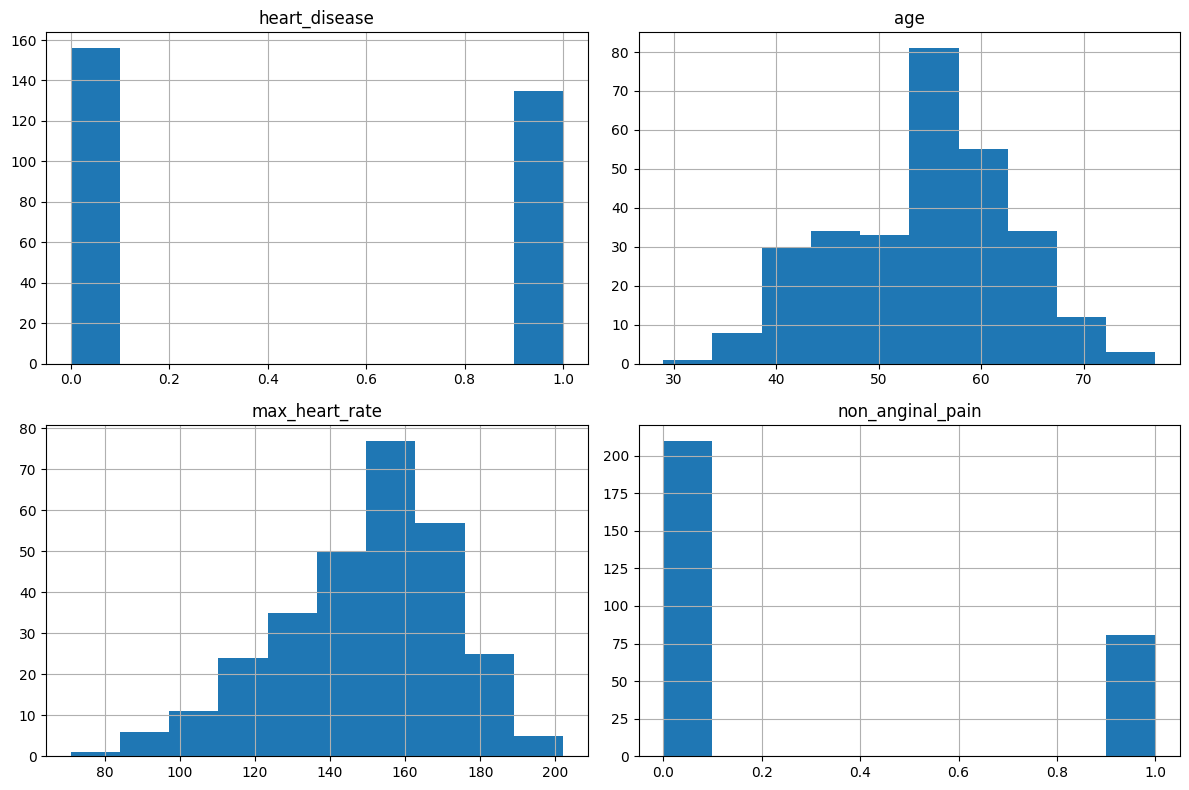

In [ ]:
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

## Histogram Insights

The histograms provide insights into the distribution of key variables:

- The target variable (heart_disease) is binary and relatively balanced.
- The age variable appears approximately normally distributed, with most individuals between 40 and 65 years old.
- Maximum heart rate also shows a roughly normal distribution, indicating a reasonable spread of values without extreme skewness.
- The non_anginal_pain variable is binary, with more observations in one category, suggesting a potential imbalance in this feature.

Overall, the variables appear well-distributed, with no severe skewness or extreme outliers, making the dataset suitable for modeling.

#Step 10 Boxplots

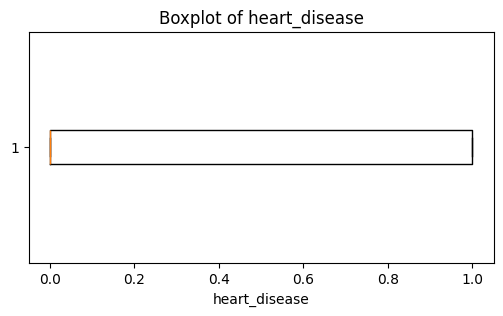

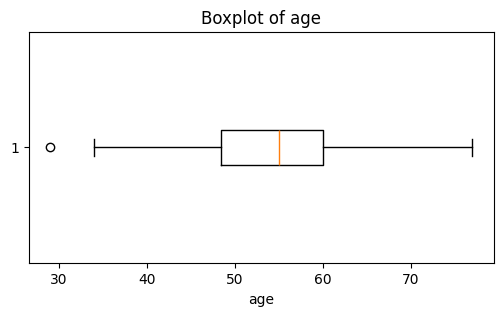

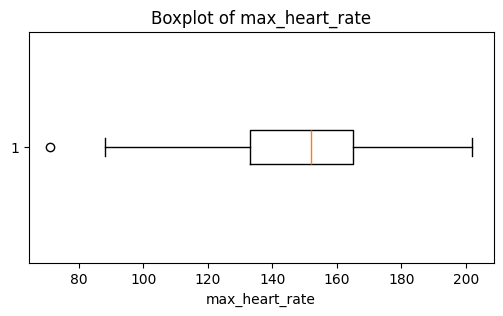

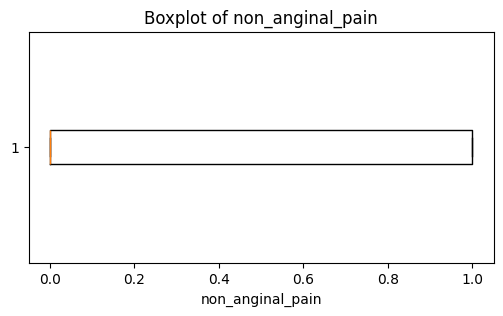

In [ ]:
for col in df.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(6, 3))
    plt.boxplot(df[col], vert=False)
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

## Step 10: Boxplot Insights

The boxplots provide insight into the spread and potential outliers in the dataset:

- The age variable shows a median around the mid-50s, with most values between 40 and 65. A small number of lower-value outliers are present.
- The max_heart_rate variable has a median around 150, with most observations falling within a reasonable range. A few lower outliers are observed.
- The heart_disease and non_anginal_pain variables are binary, so boxplots are less informative for these features.

Overall, while a few outliers are present, they do not appear extreme enough to require removal at this stage. The dataset remains suitable for modeling.

Outliers will be monitored during modeling, but are retained for now to preserve data integrity.

#STEP 11: Relationship with Target

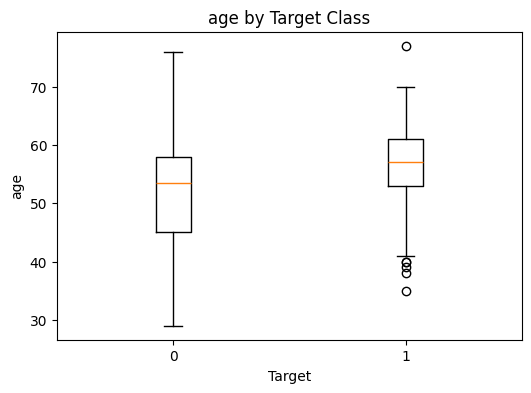

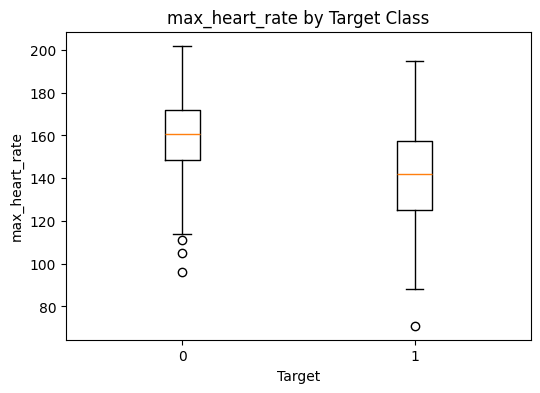

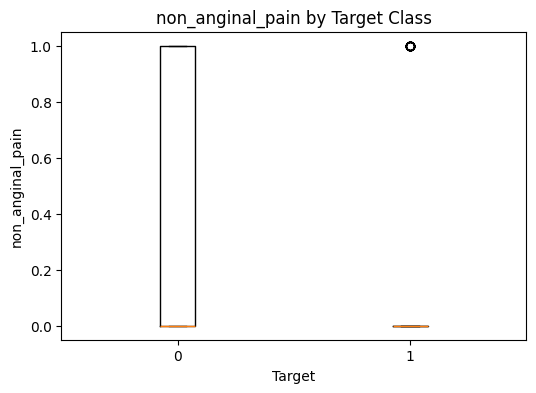

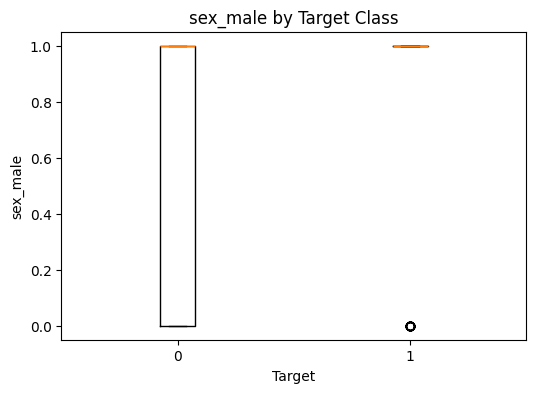

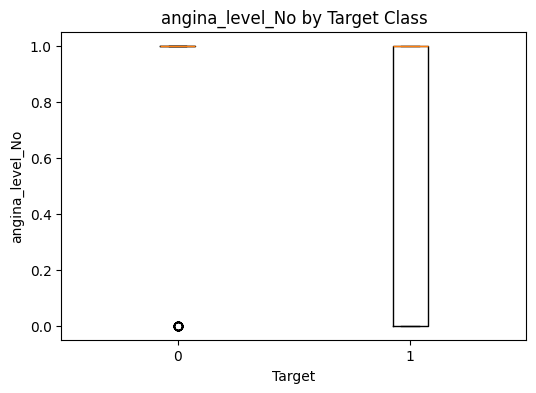

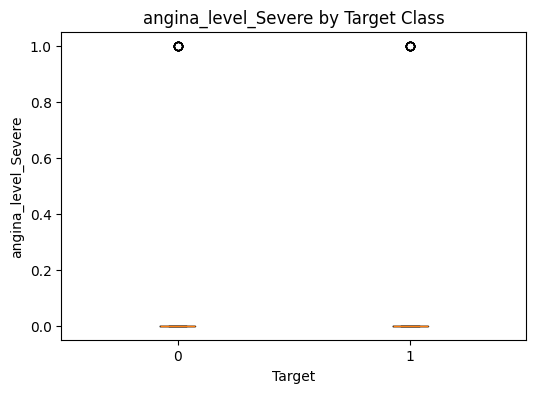

In [ ]:
predictors = df.columns[1:]

for col in predictors:
    plt.figure(figsize=(6, 4))

    x0 = df[df[target] == 0][col].astype(float)
    x1 = df[df[target] == 1][col].astype(float)

    plt.boxplot([x0, x1], tick_labels=[0, 1])
    plt.title(f'{col} by Target Class')
    plt.xlabel('Target')
    plt.ylabel(col)
    plt.show()

## Step 11: Relationship Between Predictors and Target

Boxplots were used to compare predictor distributions across the two target classes.

The plots suggest that:
- Individuals with heart disease tend to be slightly older on average.
- The heart disease group appears to have a somewhat lower maximum heart rate.
- Male patients appear more frequently in the heart disease group.
- Angina-related variables show differences across the two classes, suggesting they may be useful predictors.

Overall, several predictors appear to vary by target class, indicating that they may have predictive value in a future classification model.

#Step 12 Correlation Matrix

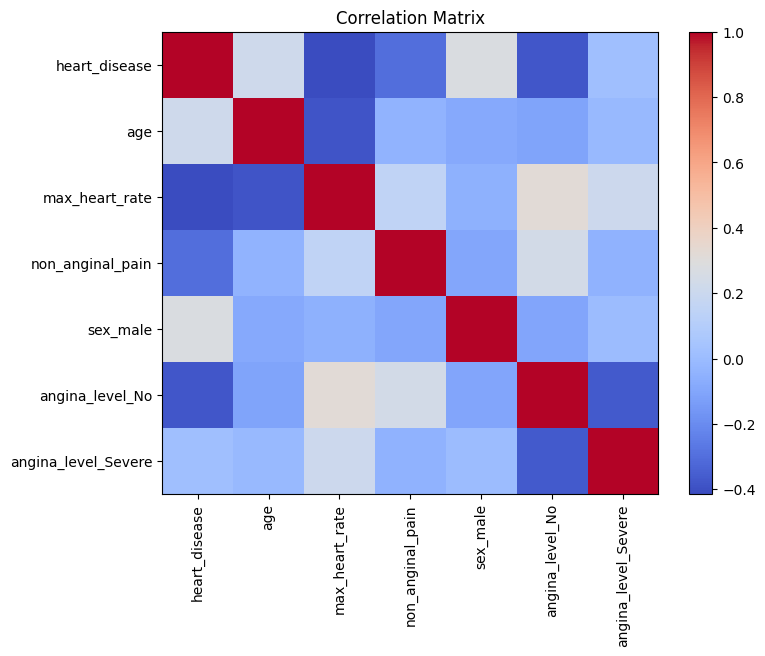

In [ ]:
plt.figure(figsize=(8, 6))
corr = df.corr(numeric_only=True)
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Matrix')
plt.show()

## Step 12: Correlation Analysis

The correlation matrix shows the relationships between variables in the dataset.

Key observations include:

- The target variable (heart_disease) shows a positive correlation with sex_male and angina_level_Severe, suggesting these variables may increase the likelihood of heart disease.
- A negative correlation is observed between heart_disease and max_heart_rate, indicating that lower maximum heart rates may be associated with heart disease.
- angina_level_No is negatively correlated with heart_disease, suggesting that the absence of angina is associated with a lower likelihood of disease.
- Other variables, such as age and non_anginal_pain, show weaker correlations with the target.

Overall, several predictors appear to have meaningful relationships with the target variable, supporting their potential usefulness in a classification model.

#Key EDA Findings
## Step 13: Key EDA Findings

The exploratory data analysis revealed several important insights:

- The dataset is structured as a binary classification problem, with heart_disease as the target variable.
- A total of 49 missing values were identified and handled using imputation.
- Categorical variables (sex and angina_level) were successfully converted into numerical format using one-hot encoding.
- The target variable is relatively balanced, with 53.6% in class 0 and 46.4% in class 1.
- Most individuals in the dataset are middle-aged, and the numerical variables show reasonable distributions with only minor outliers.
- Several predictors, including age, max_heart_rate, sex, and angina-related variables, show differences across target classes.
- Correlation analysis indicates that some variables have meaningful relationships with the target variable, particularly sex, angina level, and maximum heart rate.

Overall, the dataset appears clean, well-structured, and suitable for building a classification model.

# 3. Model Selection

For this classification problem, a suitable model is
##**Logistic Regression**.

## Justification
- The target variable (heart_disease) is binary (0 or 1), making this a classification problem.
- Logistic Regression is simple, interpretable, and commonly used for binary classification.
- It provides a strong baseline model before exploring more complex algorithms.
- It is especially useful in healthcare contexts where interpretability is important.

In a full implementation, the data would be split into training and testing sets, and the model would be trained on the training data.

 # 4. Model Evaluation

To evaluate the performance of the classification model, several metrics can be used:

- **Accuracy**: measures the overall percentage of correct predictions.
- **Precision**: measures how many predicted positive cases are actually positive.
- **Recall**: measures how many actual positive cases are correctly identified.
- **F1-score**: balances precision and recall.
- **Confusion Matrix**: provides a detailed breakdown of correct and incorrect predictions.

## Importance of Evaluation

Evaluating model performance is important to ensure that the model generalizes well to unseen data. Using multiple metrics provides a more complete understanding of model performance, especially when dealing with imbalanced datasets.